In [18]:
import pandas as pd

In [19]:
DATA_PATH = 'heart.csv'
df = pd.read_csv(DATA_PATH)

df.head()

print('Missing values by column:')
print(df.isna().sum())
print('\nAny missing values in dataset?', df.isna().any().any())

Missing values by column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Any missing values in dataset? False


In [20]:
jumlah = df.count()
jumlah

Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
dtype: int64

In [21]:
target_n = df['HeartDisease'].value_counts().max()

df_hd_balanced = (
    df
    .groupby('HeartDisease', group_keys=False)
    .apply(lambda g: g.sample(n=target_n, replace=True))
    .reset_index(drop=True)
)

C:\Users\MS1\AppData\Local\Temp\ipykernel_12664\3247962587.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=target_n, replace=True))



Outlier summary for HeartDisease = 0
  Age: 0 outliers (0.00%)
  RestingBP: 10 outliers (2.44%)
  Cholesterol: 29 outliers (7.07%)
  MaxHR: 4 outliers (0.98%)
  Oldpeak: 37 outliers (9.02%)

Outlier summary for HeartDisease = 1
  Age: 6 outliers (1.18%)
  RestingBP: 8 outliers (1.57%)
  Cholesterol: 0 outliers (0.00%)
  MaxHR: 3 outliers (0.59%)
  Oldpeak: 2 outliers (0.39%)

Total rows before outlier removal: 918
Total rows after removing outliers: 830
Removed 88 rows where numeric outlier share was under 20%

HeartDisease distribution after cleaning (before SMOTE):
HeartDisease
1    490
0    340
Name: count, dtype: int64

Balanced HeartDisease counts after SMOTE:
HeartDisease
0    490
1    490
Name: count, dtype: int64

Outlier summary after preprocessing (balanced data):

HeartDisease = 0
  Age: 2 outliers (0.41%)
  RestingBP: 3 outliers (0.61%)
  Cholesterol: 4 outliers (0.82%)
  MaxHR: 0 outliers (0.00%)
  Oldpeak: 69 outliers (14.08%)

HeartDisease = 1
  Age: 0 outliers (0.00%)


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_1,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,-1.342724,0.545724,0.853838,1.332843,-0.758417,0.530137,1.708801,-0.525397,-0.200847,-0.50637,0.743700,-0.448308,-0.747013,-0.895249,0.991870,0
1,-0.381768,1.787444,-0.255412,0.693065,0.255203,-1.886303,-0.585206,1.903324,-0.200847,-0.50637,0.743700,-0.448308,-0.747013,1.117008,-1.008197,1
2,-1.663043,-0.075137,0.792779,-1.626129,-0.758417,0.530137,1.708801,-0.525397,-0.200847,-0.50637,-1.344627,2.230607,-0.747013,-0.895249,0.991870,0
3,-0.488541,0.421552,0.090593,-1.226268,0.762013,-1.886303,-0.585206,-0.525397,-0.200847,-0.50637,0.743700,-0.448308,1.338665,1.117008,-1.008197,1
4,0.152097,1.166584,-0.102763,-0.666462,-0.758417,0.530137,-0.585206,1.903324,-0.200847,-0.50637,0.743700,-0.448308,-0.747013,-0.895249,0.991870,0


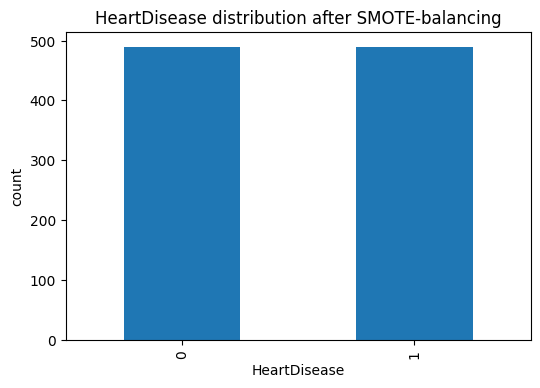

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTENC

class_col = 'HeartDisease'
cat_cols = [
    c for c in df.columns
    if c != class_col and (df[c].dtype == 'object' or df[c].nunique() < 20)
]
numeric_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c != class_col and c not in cat_cols
]

outlier_info = {}
outlier_indices = set()
for cls, group in df.groupby(class_col):
    outlier_info[cls] = {}
    total = len(group)
    for col in numeric_cols:
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (group[col] < lower) | (group[col] > upper)
        count = int(mask.sum())
        pct = 100 * count / total if total else 0
        outlier_info[cls][col] = {
            'count': count,
            'percent': pct,
            'lower': lower,
            'upper': upper,
        }
        if pct < 20 and count > 0:
            outlier_indices.update(group[mask].index)

for cls, counts in outlier_info.items():
    print(f"\nOutlier summary for {class_col} = {cls}")
    for col, stats in counts.items():
        print(f"  {col}: {stats['count']} outliers ({stats['percent']:.2f}%)")

print(f"\nTotal rows before outlier removal: {len(df)}")
df_cleaned = df.drop(index=sorted(outlier_indices)).reset_index(drop=True)
print(f"Total rows after removing outliers: {len(df_cleaned)}")
print(f"Removed {len(outlier_indices)} rows where numeric outlier share was under 20%")

print('\nHeartDisease distribution after cleaning (before SMOTE):')
print(df_cleaned[class_col].value_counts())

X = df_cleaned.drop(columns=[class_col])
y = df_cleaned[class_col]
encoders = {}
X_enc = X.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    encoders[col] = le

cat_indices = [X_enc.columns.get_loc(col) for col in cat_cols]

smote = SMOTENC(categorical_features=cat_indices, random_state=42)
X_smote, y_smote = smote.fit_resample(X_enc, y)

df_smote = pd.DataFrame(X_smote, columns=X_enc.columns)
df_smote[class_col] = y_smote
for col in cat_cols:
    df_smote[col] = encoders[col].inverse_transform(df_smote[col].astype(int))

print("\nBalanced HeartDisease counts after SMOTE:")
print(df_smote[class_col].value_counts())

df_balanced = df_smote.copy()

post_outlier_info = {}
for cls, group in df_balanced.groupby(class_col):
    post_outlier_info[cls] = {}
    total = len(group)
    for col in numeric_cols:
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (group[col] < lower) | (group[col] > upper)
        count = int(mask.sum())
        pct = 100 * count / total if total else 0
        post_outlier_info[cls][col] = {
            'count': count,
            'percent': pct,
        }

print("\nOutlier summary after preprocessing (balanced data):")
for cls, counts in post_outlier_info.items():
    print(f"\n{class_col} = {cls}")
    for col, stats in counts.items():
        print(f"  {col}: {stats['count']} outliers ({stats['percent']:.2f}%)")

print("\nTotal rows after preprocessing:", len(df_balanced))

print("\nEncoding categorical variables...")
df_encoded = pd.get_dummies(df_balanced, columns=cat_cols, drop_first=True)
feature_cols = [c for c in df_encoded.columns if c != class_col]

scaler = StandardScaler()
joblib.dump(scaler, 'scaler.joblib')
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled[class_col] = df_encoded[class_col].astype(int)

df_scaled.to_csv('heart_preprocessed.csv', index=False)
print('\nSaved preprocessed dataset to heart_preprocessed.csv')

print("\nFinal dataset shape after encoding and scaling:", df_scaled.shape)
display(df_scaled.head())

plt.figure(figsize=(6, 4))
df_balanced[class_col].value_counts().sort_index().plot(kind='bar')
plt.title('HeartDisease distribution after SMOTE-balancing')
plt.xlabel('HeartDisease')
plt.ylabel('count')

plt.show()

In [23]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].nunique() < 20]
for c in cat_cols:
    print(f"\n=== {c} ===")
    print(df[c].value_counts(dropna=False))
    print('nunique', df[c].nunique())


=== Sex ===
Sex
M    725
F    193
Name: count, dtype: int64
nunique 2

=== ChestPainType ===
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
nunique 4

=== FastingBS ===
FastingBS
0    704
1    214
Name: count, dtype: int64
nunique 2

=== RestingECG ===
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
nunique 3

=== ExerciseAngina ===
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
nunique 2

=== ST_Slope ===
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
nunique 3

=== HeartDisease ===
HeartDisease
1    508
0    410
Name: count, dtype: int64
nunique 2
